# Data Science & Cool Visualizations — docDianaSanchez dummy bookings

This notebook uses **dummy data** generated to match your real booking schema
(`backend/app.py`). Nothing here touches your live Postgres DB.

We'll learn the core data-science flow:
1. **Load** data with pandas
2. **Clean / wrangle** it (parse dates, derive features)
3. **Explore** with `value_counts`, `groupby`, `describe`
4. **Visualize** from simple bar charts to interactive dashboards

Run each cell in order (Shift+Enter). Knobs to tweak are marked `# TRY`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Nice default styling for matplotlib/seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded.")

Libraries loaded.


## 1. Load the data

`pd.read_csv` is the most common first step. `head()` shows the first rows.

In [2]:
df = pd.read_csv("bookings.csv")
print("Shape:", df.shape)        # rows, columns
print("\nColumns:", list(df.columns))
df.head(5)

Shape: (1500, 12)

Columns: ['name', 'email', 'phone', 'preferred_date', 'preferred_time', 'service', 'device_type', 'device_os', 'device_browser', 'ip_city', 'ip_country', 'created_at']


,name,email,phone,preferred_date,preferred_time,service,device_type,device_os,device_browser,ip_city,ip_country,created_at
0,Diego Lopez,diego.lopez95@hotmail.com,34826600539,2026-02-11,15:00,Atención Pediátrica,Mobile,iOS,Edge,Bogota,CO,2026-02-11 08:00
1,Tomas Garcia,tomas.garcia92@hotmail.com,1550455977,2026-07-17,09:00,Symptomatic IV,Mobile,Windows,Safari,Barcelona,ES,2026-07-17 16:00
2,Emma Perez,emma.perez12@gmail.com,54203848421,2026-06-14,10:00,Enfermedades Crónicas,Mobile,Linux,Firefox,Madrid,ES,2026-06-14 16:00
3,Valeria Rodriguez,valeria.rodriguez81@yahoo.com,1488302652,2026-07-13,14:00,B-Complex IV,Desktop,iOS,Safari,Ciudad de Mexico,MX,2026-07-13 15:00
4,Hugo Lopez,hugo.lopez49@gmail.com,57586845604,2026-05-27,15:00,Enfermedades Crónicas,Desktop,Android,Firefox,Miami,US,2026-05-27 10:00


## 2. Clean / wrangle

Raw dates are text. Convert to real `datetime` so we can do math on them,
then derive useful features: `weekday`, `month`, `hour`.

In [3]:
df["preferred_date"] = pd.to_datetime(df["preferred_date"])   # text -> date
df["weekday"] = df["preferred_date"].dt.day_name()
df["month"] = df["preferred_date"].dt.to_period("M").astype(str)
df["iso_week"] = df["preferred_date"].dt.isocalendar().week
df["hour"] = df["preferred_time"].str.slice(0, 2).astype(int)

print("Now:", df.shape)
df[["preferred_date", "weekday", "month", "hour", "service"]].head()

Now: (1500, 16)


,preferred_date,weekday,month,hour,service
0,2026-02-11,Wednesday,2026-02,15,Atención Pediátrica
1,2026-07-17,Friday,2026-07,9,Symptomatic IV
2,2026-06-14,Sunday,2026-06,10,Enfermedades Crónicas
3,2026-07-13,Monday,2026-07,14,B-Complex IV
4,2026-05-27,Wednesday,2026-05,15,Enfermedades Crónicas


## 3. Quick exploration (the "feel" of the data)

- `value_counts()` — frequency of each category
- `describe()` — summary stats for numbers
- `groupby()` — aggregate by a category

In [4]:
print("=== Bookings per service ===")
print(df["service"].value_counts())
print("\n=== Bookings per country ===")
print(df["ip_country"].value_counts())
print("\n=== Device split ===")
print(df["device_type"].value_counts(normalize=True).round(3))

=== Bookings per service ===
service
Vitamin C IV             277
IV Rehydration           164
B-Complex IV             160
Consulta General         137
Facial Harmonization     128
Symptomatic IV           117
Enfermedades Crónicas    109
Medicina Preventiva      106
General Consultation     104
Visita Domiciliaria       84
Consulta Virtual          64
Atención Pediátrica       50
Name: count, dtype: int64

=== Bookings per country ===
ip_country
ES    639
MX    311
CO    304
AR    129
US    117
Name: count, dtype: int64

=== Device split ===
device_type
Mobile     0.615
Desktop    0.319
Tablet     0.066
Name: proportion, dtype: float64


## 4. The classic bar chart (Seaborn)

Which services are most popular? Sort + horizontal bars read best.

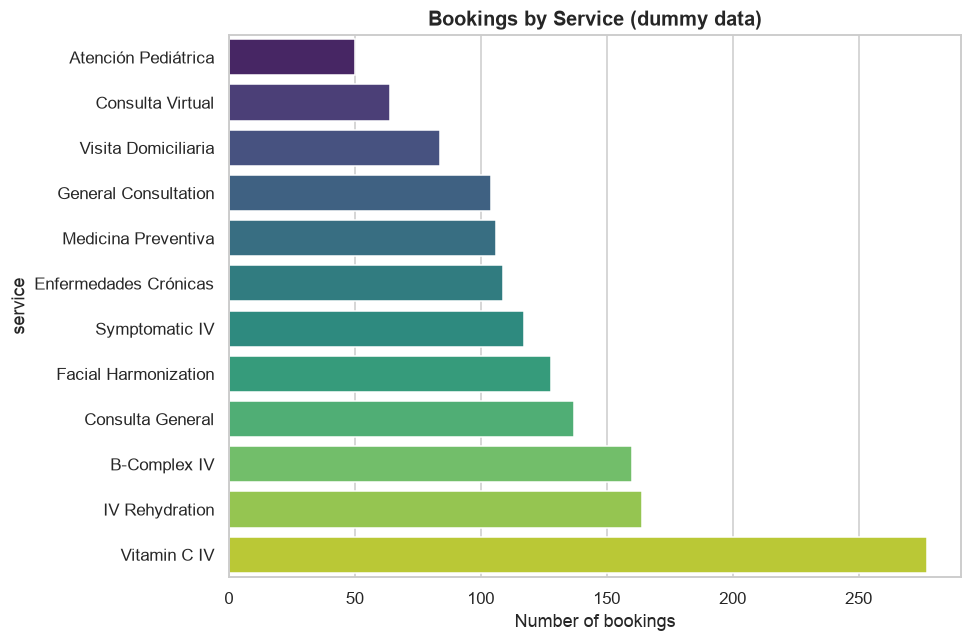

In [5]:
svc = df["service"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=svc.values, y=svc.index, ax=ax, hue=svc.index, palette="viridis", legend=False)
ax.set_title("Bookings by Service (dummy data)", fontsize=13, weight="bold")
ax.set_xlabel("Number of bookings")
plt.tight_layout()
plt.show()

## 5. Time series — bookings per month (line chart)

A line chart reveals **trends**. Our generator added slight growth, so you
should see bookings climb over recent months.

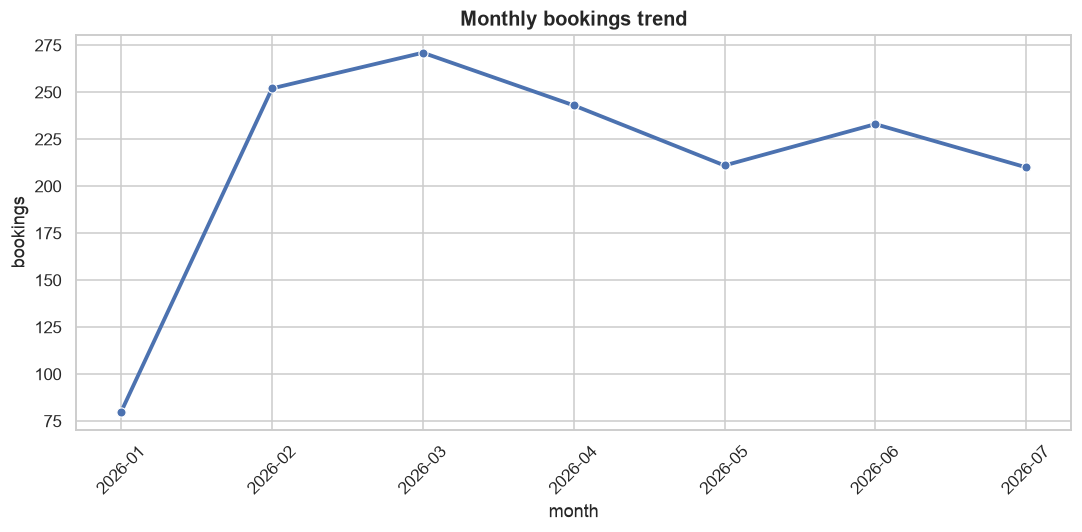

In [6]:
monthly = df.groupby("month").size().reset_index(name="bookings")
fig, ax = plt.subplots()
sns.lineplot(data=monthly, x="month", y="bookings", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Monthly bookings trend", fontsize=13, weight="bold")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 6. Heatmap — weekday x hour demand

Cross-tabulation + a color heatmap shows **when** the clinic is busiest.
This is one of the most useful views for staffing/scheduling.

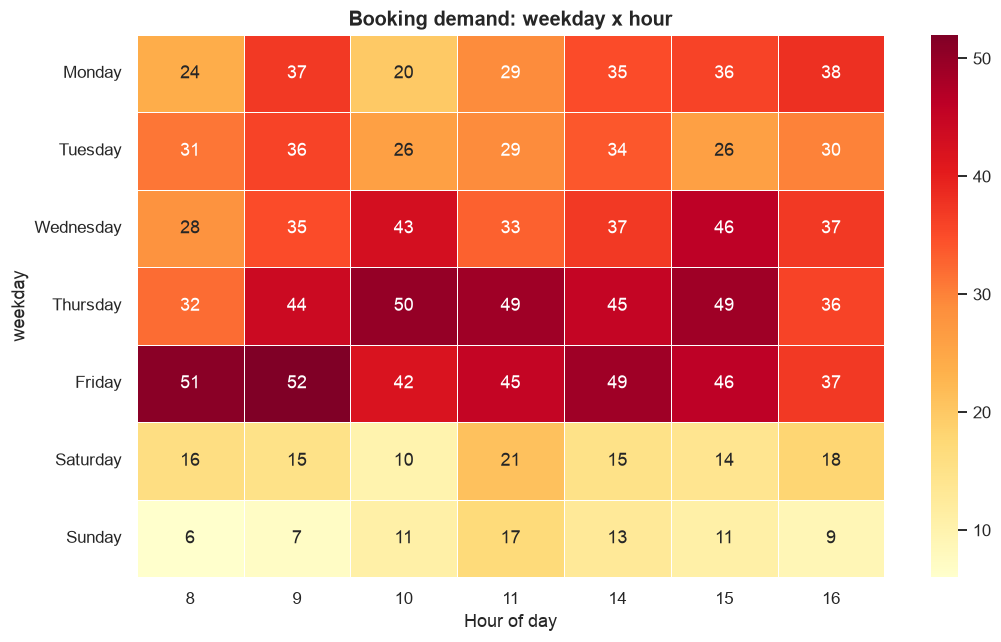

In [7]:
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = df.pivot_table(index="weekday", columns="hour", aggfunc="size", fill_value=0)
pivot = pivot.reindex(order_days)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt="d", linewidths=.5, ax=ax)
ax.set_title("Booking demand: weekday x hour", fontsize=13, weight="bold")
ax.set_xlabel("Hour of day")
plt.tight_layout()
plt.show()

## 7. Interactive chart (Plotly) — service by country

Plotly makes **hover-able, zoom-able** charts that render in a browser/HTML.
Hover a bar to see exact counts. Click a legend item to hide a series.

In [8]:
ct = df.groupby(["ip_country", "service"]).size().reset_index(name="bookings")
fig = px.bar(
    ct, x="service", y="bookings", color="ip_country",
    title="Bookings by Service & Country (interactive)",
    barmode="group", height=500,
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

## 8. Treemap — composition at a glance

Treemaps show **part-to-whole** relationships with area. Great for
"what makes up our bookings" questions.

In [9]:
tm = df.groupby(["ip_country", "service"]).size().reset_index(name="bookings")
fig = px.treemap(
    tm, path=[px.Constant("All bookings"), "ip_country", "service"],
    values="bookings", title="Booking composition by country -> service",
)
fig.show()

## 9. Scatter / bubble — device vs time, sized by volume

Bubble charts encode a 3rd dimension with size. Here: weekday vs hour,
bubble size = number of bookings, color = device.

In [10]:
bub = df.groupby(["weekday", "hour", "device_type"]).size().reset_index(name="n")
bub["weekday"] = pd.Categorical(bub["weekday"], order_days, ordered=True)
bub = bub.sort_values("weekday")
fig = px.scatter(
    bub, x="hour", y="weekday", size="n", color="device_type",
    size_max=40, title="Booking bubbles: when & on what device",
    hover_name="device_type",
)
fig.show()

## 10. Dashboard-style subplot grid (Plotly)

Combine several views into one panel — the start of a real "dashboard".

In [11]:
svc_top = df["service"].value_counts().head(8).sort_values()
dev = df["device_type"].value_counts()
wk = df["weekday"].value_counts().reindex(order_days)

fig = make_subplots(
    rows=1, cols=3, subplot_titles=("Top services", "Device split", "By weekday"),
    specs=[[{"type": "bar"}, {"type": "pie"}, {"type": "bar"}]],
)
fig.add_bar(y=svc_top.index, x=svc_top.values, orientation="h", row=1, col=1, marker_color="#4C72B0")
fig.add_pie(labels=dev.index, values=dev.values, row=1, col=2, hole=0.4)
fig.add_bar(x=wk.index, y=wk.values, row=1, col=3, marker_color="#55A868")
fig.update_layout(height=420, showlegend=False, title_text="docDianaSanchez — bookings overview (dummy)")
fig.show()

## 11. Save an interactive HTML dashboard

Export the last figure so you can open it in any browser or share it.
**TRY**: change `fig` to any Plotly figure above and re-save.

In [12]:
fig.write_html("dashboard.html")
print("Saved dashboard.html — open it in a browser!")

Saved dashboard.html — open it in a browser!


## What you learned

- **pandas** loads & wrangles (read_csv, to_datetime, groupby, pivot_table)
- **seaborn/matplotlib** for static, publication-style plots
- **plotly** for interactive, browser-ready charts & dashboards
- The data-science loop: load → clean → explore → visualize

### Next exercises (change the data, re-run)
1. Regenerate with a different `random.seed` in `generate_bookings.py`.
2. Add a new column (e.g. `price`) and make a histogram: `px.histogram(df, x='price')`.
3. Filter to one country: `mx = df[df.ip_country=='MX']` and re-chart.
4. Swap the CSV for your real DB later by pointing `pd.read_sql` at Postgres.